# Module 1: Understanding Loss Functions - Zero-One Loss vs Squared Loss

**Learning Objectives:**
- Understand what loss functions measure and why they matter
- Compare zero-one loss (classification) and squared loss (regression)
- Visualize how each loss function behaves
- Recognize when to use each loss function

---

## What is a Loss Function?

A **loss function** measures how "wrong" our prediction is compared to the true value. It's the foundation of how models learn - they try to minimize this loss.

Different tasks need different loss functions:
- **Classification**: Did we get the label right or wrong?
- **Regression**: How far off was our numerical prediction?

In [1]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import log_loss, mean_squared_error
import scipy.stats as stats
from scipy.optimize import minimize_scalar
import numpy as np
from matplotlib import pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

/Users/shivin/miniconda/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


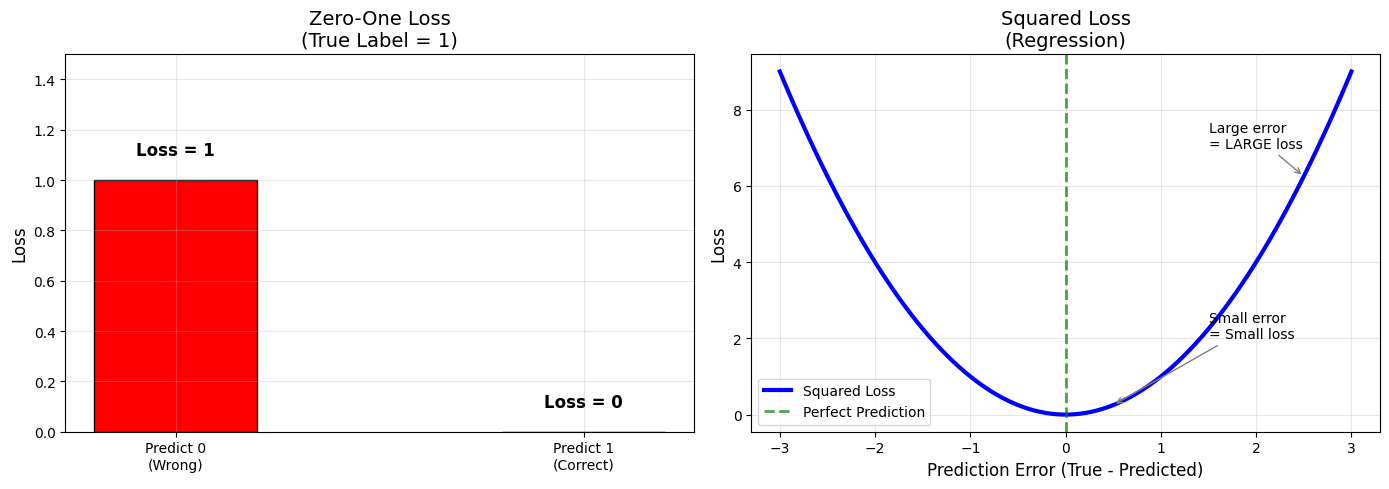

Key Insight:
- Zero-One Loss: Binary (0 or 1) - only cares if you're right or wrong
- Squared Loss: Continuous - penalizes larger errors much more heavily


In [2]:
# Define the two loss functions

def zero_one_loss(y_true, y_pred):
    """
    Zero-One Loss: Returns 0 if prediction is correct, 1 if wrong.
    Used for classification tasks.
    """
    return 0 if y_true == y_pred else 1

def squared_loss(y_true, y_pred):
    """
    Squared Loss: Returns the square of the difference.
    Used for regression tasks.
    """
    return (y_true - y_pred) ** 2

# Visualize both loss functions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Zero-One Loss
ax1 = axes[0]
# For binary classification with true label = 1
predictions = np.array([0, 1])
losses = [zero_one_loss(1, p) for p in predictions]
colors = ['red', 'green']
ax1.bar(predictions, losses, color=colors, edgecolor='black', width=0.4)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Predict 0\n(Wrong)', 'Predict 1\n(Correct)'])
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Zero-One Loss\n(True Label = 1)', fontsize=14)
ax1.set_ylim(0, 1.5)
ax1.grid(True, alpha=0.3)
for i, (x, y) in enumerate(zip(predictions, losses)):
    ax1.annotate(f'Loss = {y}', (x, y + 0.1), ha='center', fontsize=12, fontweight='bold')

# Right plot: Squared Loss
ax2 = axes[1]
errors = np.linspace(-3, 3, 100)  # (y_true - y_pred)
squared_losses = errors ** 2

ax2.plot(errors, squared_losses, 'b-', linewidth=3, label='Squared Loss')
ax2.axvline(x=0, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Perfect Prediction')
ax2.set_xlabel('Prediction Error (True - Predicted)', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Squared Loss\n(Regression)', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Add annotations
ax2.annotate('Small error\n= Small loss', xy=(0.5, 0.25), xytext=(1.5, 2),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax2.annotate('Large error\n= LARGE loss', xy=(2.5, 6.25), xytext=(1.5, 7),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)

plt.tight_layout()
plt.show()

print("Key Insight:")
print("- Zero-One Loss: Binary (0 or 1) - only cares if you're right or wrong")
print("- Squared Loss: Continuous - penalizes larger errors much more heavily")

## Part A: Zero-One Loss in Action (Classification)

Zero-one loss is the natural way to measure classification performance:
- **Loss = 0** if prediction matches the true label (correct!)
- **Loss = 1** if prediction differs from true label (wrong!)

The **average zero-one loss** across all samples gives us the **error rate**.  
And `1 - error rate` = **accuracy**!

In [ ]:
# Generate 2D classification data
np.random.seed(42)

# Class 0: cluster centered at (2, 2)
class_0_x = np.random.normal(2, 0.8, 30)
class_0_y = np.random.normal(2, 0.8, 30)

# Class 1: cluster centered at (5, 5)
class_1_x = np.random.normal(5, 0.8, 30)
class_1_y = np.random.normal(5, 0.8, 30)

# Combine data
X_class = np.column_stack([np.concatenate([class_0_x, class_1_x]),
                           np.concatenate([class_0_y, class_1_y])])
y_class = np.array([0]*30 + [1]*30)

# Train a simple classifier (Logistic Regression)
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_class, y_class)

# Make predictions
y_pred_class = classifier.predict(X_class)

# Calculate zero-one loss for each point
individual_losses = [zero_one_loss(true, pred) for true, pred in zip(y_class, y_pred_class)]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Classification results with colors showing correct/incorrect
ax1 = axes[0]
for i in range(len(X_class)):
    if individual_losses[i] == 0:  # Correct prediction
        color = 'green'
        marker = 'o'
    else:  # Incorrect prediction
        color = 'red'
        marker = 'x'
    ax1.scatter(X_class[i, 0], X_class[i, 1], c=color, marker=marker, s=100, alpha=0.7)

# Draw decision boundary
xx, yy = np.meshgrid(np.linspace(0, 7, 100), np.linspace(0, 7, 100))
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)

ax1.set_xlabel('Feature 1', fontsize=12)
ax1.set_ylabel('Feature 2', fontsize=12)
ax1.set_title('Classification with Zero-One Loss\nGreen = Correct (Loss=0), Red = Wrong (Loss=1)', fontsize=12)
ax1.legend(['Decision Boundary'], loc='upper left')
ax1.grid(True, alpha=0.3)

# Right plot: Summary statistics
ax2 = axes[1]
n_correct = sum(1 for l in individual_losses if l == 0)
n_wrong = sum(1 for l in individual_losses if l == 1)
total = len(individual_losses)

bars = ax2.bar(['Correct\n(Loss=0)', 'Wrong\n(Loss=1)'], [n_correct, n_wrong], 
               color=['green', 'red'], edgecolor='black', width=0.5)
ax2.set_ylabel('Number of Samples', fontsize=12)
ax2.set_title('Zero-One Loss Summary', fontsize=14)
ax2.set_ylim(0, total + 5)

# Add count labels on bars
for bar, count in zip(bars, [n_correct, n_wrong]):
    ax2.annotate(f'{count}', (bar.get_x() + bar.get_width()/2, bar.get_height() + 1),
                ha='center', fontsize=14, fontweight='bold')

ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary
total_loss = sum(individual_losses)
avg_loss = total_loss / len(individual_losses)
accuracy = 1 - avg_loss

print(f"\nResults:")
print(f"  Total samples: {total}")
print(f"  Correct predictions: {n_correct}")
print(f"  Wrong predictions: {n_wrong}")
print(f"  Total Zero-One Loss: {total_loss}")
print(f"  Average Zero-One Loss (Error Rate): {avg_loss:.3f}")
print(f"  Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

### Discussion Questions - Zero-One Loss

**Question 2.1:** If a classifier is "almost right" (e.g., predicts class 1 with 51% confidence when the true class is 0), how does zero-one loss treat this compared to being "completely wrong" (99% confidence in the wrong class)?

**Question 2.2:** Why might zero-one loss be problematic for training a model using gradient descent?

**Question 2.3:** In what situations would zero-one loss be the most appropriate metric to report?

## Part B: Squared Loss in Action (Regression)

Squared loss is the standard choice for regression problems:
- **Loss = (true - predicted)²**
- Small errors → small loss
- Large errors → **very large** loss (quadratic penalty!)

The **average squared loss** across all samples is the **Mean Squared Error (MSE)**.

In [ ]:
# Generate regression data
np.random.seed(42)
n_points = 15
X_reg = np.linspace(0, 10, n_points)
y_true_reg = 2 * X_reg + 3  # True line: y = 2x + 3
y_reg = y_true_reg + np.random.normal(0, 2, n_points)  # Add noise

# Fit a linear regression
from sklearn.linear_model import LinearRegression
reg_model = LinearRegression()
reg_model.fit(X_reg.reshape(-1, 1), y_reg)
y_pred_reg = reg_model.predict(X_reg.reshape(-1, 1))

# Calculate individual squared losses
individual_sq_losses = [(y_reg[i] - y_pred_reg[i])**2 for i in range(len(y_reg))]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Regression with visual squared errors
ax1 = axes[0]

# Plot the fitted line
x_line = np.linspace(-0.5, 10.5, 100)
y_line = reg_model.predict(x_line.reshape(-1, 1))
ax1.plot(x_line, y_line, 'b-', linewidth=2, label='Fitted Line', zorder=1)

# Plot data points and error squares
for i in range(len(X_reg)):
    # Draw vertical line (error)
    ax1.plot([X_reg[i], X_reg[i]], [y_pred_reg[i], y_reg[i]], 'r-', linewidth=1, alpha=0.5)
    
    # Draw a small "square" to represent squared error (visual representation)
    error = abs(y_reg[i] - y_pred_reg[i])
    if error > 0.5:  # Only draw visible squares
        # Scale the square for visibility
        square_size = min(error * 0.3, 1.5)
        rect = plt.Rectangle((X_reg[i] - square_size/2, min(y_reg[i], y_pred_reg[i])),
                             square_size, error, 
                             fill=True, facecolor='red', alpha=0.2, edgecolor='red', linewidth=1)
        ax1.add_patch(rect)

# Plot data points on top
ax1.scatter(X_reg, y_reg, c='darkblue', s=100, zorder=3, label='Data Points', edgecolors='white')

ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Regression with Squared Loss\nRed areas represent the squared errors', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)

# Right plot: Bar chart of individual squared losses
ax2 = axes[1]
colors = ['red' if loss > np.mean(individual_sq_losses) else 'orange' for loss in individual_sq_losses]
bars = ax2.bar(range(len(individual_sq_losses)), individual_sq_losses, color=colors, edgecolor='black', alpha=0.7)
ax2.axhline(y=np.mean(individual_sq_losses), color='blue', linestyle='--', linewidth=2, 
            label=f'MSE = {np.mean(individual_sq_losses):.2f}')
ax2.set_xlabel('Data Point Index', fontsize=12)
ax2.set_ylabel('Squared Loss', fontsize=12)
ax2.set_title('Squared Loss per Data Point', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nResults:")
print(f"  Number of points: {n_points}")
print(f"  Individual squared losses: {[f'{l:.2f}' for l in individual_sq_losses]}")
print(f"  Sum of squared losses: {sum(individual_sq_losses):.2f}")
print(f"  Mean Squared Error (MSE): {np.mean(individual_sq_losses):.2f}")
print(f"  Root MSE (RMSE): {np.sqrt(np.mean(individual_sq_losses)):.2f}")
print(f"\nNotice how larger errors contribute MUCH more to the total loss!")

### Discussion Questions - Squared Loss

**Question 2.4:** Why does squared loss penalize large errors more than small errors? Is this always desirable?

**Question 2.5:** If you have an outlier (a data point very far from the others), how will it affect the model trained with squared loss?

**Question 2.6:** Why is squared loss preferred over absolute loss (|true - predicted|) for training models?

## Part C: Why Different Losses? A Critical Comparison

Now let's see why we need different loss functions for different tasks and understand their key properties.

In [ ]:
# Comparison 1: Shape of the loss functions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Loss function shapes
ax1 = axes[0]
errors = np.linspace(-3, 3, 200)

# Squared loss
squared = errors ** 2
ax1.plot(errors, squared, 'b-', linewidth=3, label='Squared Loss')

# Absolute loss (for comparison)
absolute = np.abs(errors)
ax1.plot(errors, absolute, 'g-', linewidth=3, label='Absolute Loss')

# Zero-one loss (step function approximation for continuous visualization)
zero_one_continuous = np.where(np.abs(errors) > 0.5, 1, 0)
ax1.step(errors, zero_one_continuous, 'r-', linewidth=3, where='mid', label='Zero-One Loss (approx)')

ax1.set_xlabel('Prediction Error', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Comparing Loss Function Shapes', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-3, 3)
ax1.set_ylim(-0.5, 9)

# Plot 2: Gradient/Derivative (why it matters for training)
ax2 = axes[1]

# Derivative of squared loss: 2 * error
squared_derivative = 2 * errors
ax2.plot(errors, squared_derivative, 'b-', linewidth=3, label='Squared Loss Gradient')

# Derivative of absolute loss: sign(error)
absolute_derivative = np.sign(errors)
ax2.plot(errors, absolute_derivative, 'g-', linewidth=3, label='Absolute Loss Gradient')

# Zero-one loss has no useful gradient (flat everywhere except at discontinuity)
ax2.axhline(y=0, color='red', linewidth=3, linestyle='--', label='Zero-One Loss Gradient (=0)')

ax2.set_xlabel('Prediction Error', fontsize=12)
ax2.set_ylabel('Gradient', fontsize=12)
ax2.set_title('Gradients: Why Training Matters', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-3, 3)

# Add annotation explaining the problem
ax2.annotate('Zero-One Loss gradient\nis always 0!\nCannot use gradient descent', 
            xy=(0, 0), xytext=(1, 2),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

# Plot 3: Outlier sensitivity demonstration
ax3 = axes[2]

# Normal data points
np.random.seed(42)
normal_errors = np.random.normal(0, 0.5, 10)
outlier_error = 5  # One outlier

all_errors = np.append(normal_errors, outlier_error)

# Calculate losses
sq_losses_normal = normal_errors ** 2
sq_loss_outlier = outlier_error ** 2

# Bar chart
x_positions = range(len(all_errors))
colors = ['steelblue'] * len(normal_errors) + ['red']
ax3.bar(x_positions, all_errors ** 2, color=colors, edgecolor='black', alpha=0.7)

ax3.set_xlabel('Data Point', fontsize=12)
ax3.set_ylabel('Squared Loss', fontsize=12)
ax3.set_title('Outlier Sensitivity of Squared Loss', fontsize=14)
ax3.grid(True, alpha=0.3, axis='y')

# Add annotation
ax3.annotate('One outlier dominates\nthe total loss!', 
            xy=(10, sq_loss_outlier), xytext=(7, 20),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Outlier Impact Analysis:")
print(f"  Sum of squared losses (normal points only): {sum(sq_losses_normal):.2f}")
print(f"  Squared loss from outlier alone: {sq_loss_outlier:.2f}")
print(f"  Outlier contributes {sq_loss_outlier / (sum(sq_losses_normal) + sq_loss_outlier) * 100:.1f}% of total loss!")
print("\nKey Insight: Squared loss makes models very sensitive to outliers.")

## Summary: Zero-One Loss vs Squared Loss

| Property | Zero-One Loss | Squared Loss |
|----------|---------------|--------------|
| **Used for** | Classification | Regression |
| **Formula** | 0 if correct, 1 if wrong | (true - predicted)² |
| **Range** | {0, 1} | [0, ∞) |
| **Differentiable?** | No (step function) | Yes (smooth curve) |
| **Gradient descent?** | Cannot use directly | Works well |
| **Outlier sensitivity** | Low (all errors equal) | High (large errors dominate) |
| **Intuition** | "Did you get it right?" | "How far off were you?" |

---

### Final Exercises

**Exercise 2.1:** A classifier predicts the following for 5 samples:
- Sample 1: True=1, Predicted=1
- Sample 2: True=0, Predicted=1
- Sample 3: True=1, Predicted=0
- Sample 4: True=0, Predicted=0
- Sample 5: True=1, Predicted=1

Calculate the total zero-one loss and the accuracy.

**Exercise 2.2:** A regression model predicts the following:
- True values: [10, 15, 20, 25, 30]
- Predicted values: [12, 14, 19, 26, 28]

Calculate the MSE (Mean Squared Error).

**Exercise 2.3:** Why do we use **cross-entropy loss** instead of zero-one loss when training neural networks for classification? (Hint: Think about gradients!)

**Exercise 2.4:** Give a real-world example where:
- (a) You would only care about zero-one loss (correct vs incorrect)
- (b) You would prefer squared loss (continuous error matters)

# Module 1: Understanding Overfitting and Underfitting through Curve Fitting

**Learning Objectives:**
- Understand the concepts of overfitting and underfitting using familiar curve fitting techniques
- Recognize overfitting and underfitting patterns in polynomial and Gaussian curve fitting
- Connect these concepts to previously learned algorithms (Linear Models and KNN)
- Develop intuition for the bias-variance tradeoff

## Part A: Polynomial Curve Fitting - The Foundation

Let's start with a simple scenario: You have collected some data points and want to fit a curve through them.

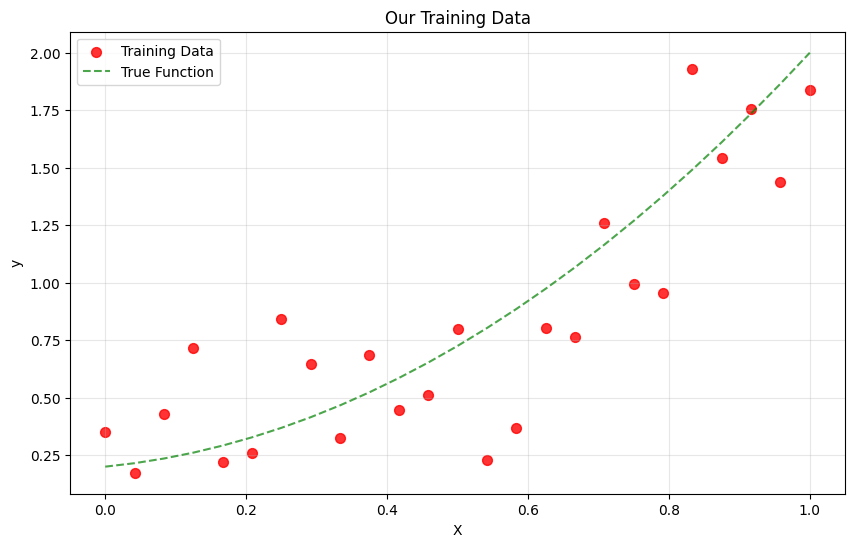

We have 25 training points
The true underlying function is quadratic: y = 1.5x² + 0.3x + 0.2


In [6]:
# Generate synthetic data with a quadratic relationship + noise
def generate_quadratic_data(n_samples=25, noise_level=0.3):
    X = np.linspace(0, 1, n_samples)
    y_true = 1.5 * X**2 + 0.3 * X + 0.2  # True quadratic relationship
    y_observed = y_true + np.random.normal(0, noise_level, n_samples) # adding some gaussian noise
    return X, y_observed, y_true

# Generate our dataset
X_train, y_train, y_true = generate_quadratic_data()

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='red', s=50, alpha=0.8, label='Training Data')
plt.plot(X_train, y_true, 'g--', alpha=0.7, label='True Function')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Our Training Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"We have {len(X_train)} training points")
print("The true underlying function is quadratic: y = 1.5x² + 0.3x + 0.2")

### Exercise 1.1: Fitting Different Polynomial Degrees

Now let's fit polynomials of different degrees to this data and see what happens.

In [7]:
# Function to fit polynomial and plot results
def fit_and_plot_polynomial(X_train, y_train, degree, subplot_pos, title_suffix=""):
    # Fit polynomial
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X_train.reshape(-1, 1))
    
    model = LinearRegression()
    model.fit(X_poly, y_train)
    
    # Generate smooth curve for plotting
    X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
    X_plot_poly = poly_features.transform(X_plot)
    y_plot = model.predict(X_plot_poly)
    
    # Calculate training error
    y_train_pred = model.predict(X_poly)
    train_error = mean_squared_error(y_train, y_train_pred)
    
    # Plot
    plt.subplot(2, 3, subplot_pos)
    plt.scatter(X_train, y_train, color='red', s=50, alpha=0.8, label='Training Data')
    plt.plot(X_plot, y_plot, 'b-', linewidth=2, label=f'Degree {degree} Fit')
    plt.plot(X_train, y_true, 'g--', alpha=0.7, label='True Function')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Degree {degree} Polynomial {title_suffix}\nTrain Error: {train_error:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.5, 2.5)
    
    return train_error

# Create comparison plot
plt.figure(figsize=(15, 10))

# Fit different degrees
degrees = [1, 2, 9, 14, 20, 40]
train_errors = []

for i, degree in enumerate(degrees):
    error = fit_and_plot_polynomial(X_train, y_train, degree, i+1)
    train_errors.append(error)

plt.tight_layout()
plt.show()

# Print errors
print("\nTraining Errors:")
for degree, error in zip(degrees, train_errors):
    print(f"Degree {degree}: {error:.4f}")

NameError: name 'PolynomialFeatures' is not defined

<Figure size 1500x1000 with 0 Axes>

### Discussion Questions:

**Question 1.1:** Looking at the plots above, which polynomial degree seems to provide the best fit to the data? Why?

**Question 1.2:** What do you notice about the training error as the polynomial degree increases?

**Question 1.3:** Which fits would you classify as:
- **Underfitting**: 
- **Good fitting**: 
- **Overfitting**: 

**Question 1.4:** What problems might you encounter if you use the degree 30/40 polynomial to predict new data points?

## Part B: Testing on New Data - The Real Test

Training error alone can be misleading. Let's see how our models perform on **new, unseen data**.

In [ ]:
# Generate new test data from the same underlying function
X_test, y_test, y_test_true = generate_quadratic_data(n_samples=20, noise_level=0.3)

def evaluate_polynomial_on_test(X_train, y_train, X_test, y_test, degree):
    # Train model
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train.reshape(-1, 1))
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Test model
    X_test_poly = poly_features.transform(X_test.reshape(-1, 1))
    y_test_pred = model.predict(X_test_poly)
    
    # Calculate errors
    train_pred = model.predict(X_train_poly)
    train_error = mean_squared_error(y_train, train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    
    return train_error, test_error

# Evaluate all degrees
degrees_range = range(1, 40)
train_errors = []
test_errors = []

for degree in degrees_range:
    train_err, test_err = evaluate_polynomial_on_test(X_train, y_train, X_test, y_test, degree)
    train_errors.append(train_err)
    test_errors.append(test_err)

# Plot the learning curve
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.plot(degrees_range, train_errors, 'b-o', label='Training Error', linewidth=2)
plt.plot(degrees_range, test_errors, 'r-s', label='Test Error', linewidth=2)
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Test Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Show the data split
plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, color='blue', s=50, alpha=0.8, label='Training Data')
plt.scatter(X_test, y_test, color='red', s=50, alpha=0.8, label='Test Data')
plt.plot(X_train, y_true, 'g--', alpha=0.7, label='True Function')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Training vs Test Data')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal degree
optimal_degree = degrees_range[np.argmin(test_errors)]
print(f"\nOptimal polynomial degree (lowest test error): {optimal_degree}")
print(f"Test error at optimal degree: {min(test_errors):.4f}")

### Key Observations:

**Question 1.5:** What happens to the test error as polynomial degree increases beyond the optimal point?

**Question 1.6:** At what degree does overfitting clearly begin? How can you tell?

**Question 1.7:** Why does the training error always decrease as degree increases, but test error doesn't?

## Part C: Gaussian Distribution Fitting

Now let's apply the same concepts to fitting Gaussian distributions - another type of curve fitting you're familiar with.

In [ ]:
# Generate data from a mixture of two Gaussians
def generate_gaussian_mixture_data(n_samples=200):
    # True mixture: 60% from N(2, 0.5²) + 40% from N(6, 0.8²)
    component1 = np.random.normal(2, 0.5, int(0.6 * n_samples))
    component2 = np.random.normal(6, 0.8, int(0.4 * n_samples))
    data = np.concatenate([component1, component2])
    np.random.shuffle(data)
    return data

# Generate our data
gaussian_data = generate_gaussian_mixture_data()

# Create histogram
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
counts, bins, _ = plt.hist(gaussian_data, bins=25, alpha=0.7, density=True, color='lightblue', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Our Data Distribution')
plt.grid(True, alpha=0.3)

# Fit single Gaussian (underfitting)
plt.subplot(1, 3, 2)
plt.hist(gaussian_data, bins=25, alpha=0.7, density=True, color='lightblue', edgecolor='black')
x_range = np.linspace(gaussian_data.min(), gaussian_data.max(), 100)
single_gaussian = stats.norm(gaussian_data.mean(), gaussian_data.std())
plt.plot(x_range, single_gaussian.pdf(x_range), 'r-', linewidth=3, label='Single Gaussian Fit')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Single Gaussian (Underfitting)')
plt.legend()
plt.grid(True, alpha=0.3)

# Fit mixture of Gaussians (good fit) - simplified version
plt.subplot(1, 3, 3)
plt.hist(gaussian_data, bins=25, alpha=0.7, density=True, color='lightblue', edgecolor='black')

# Manual two-component mixture (approximation)
left_data = gaussian_data[gaussian_data < 4]
right_data = gaussian_data[gaussian_data >= 4]

if len(left_data) > 0 and len(right_data) > 0:
    weight1 = len(left_data) / len(gaussian_data)
    weight2 = len(right_data) / len(gaussian_data)
    
    gaussian1 = stats.norm(left_data.mean(), left_data.std())
    gaussian2 = stats.norm(right_data.mean(), right_data.std())
    
    mixture_pdf = weight1 * gaussian1.pdf(x_range) + weight2 * gaussian2.pdf(x_range)
    
    plt.plot(x_range, mixture_pdf, 'g-', linewidth=3, label='Two-Component Mixture')
    plt.plot(x_range, weight1 * gaussian1.pdf(x_range), 'g--', alpha=0.5)
    plt.plot(x_range, weight2 * gaussian2.pdf(x_range), 'g--', alpha=0.5)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Two-Component Mixture (Good Fit)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 1.2: Understanding Gaussian Overfitting

In [ ]:
# Generate data from a mixture of two Gaussians (ensure it's available)
def generate_gaussian_mixture_data(n_samples=200):
    # True mixture: 60% from N(2, 0.5²) + 40% from N(6, 0.8²)
    np.random.seed(42)  # For reproducibility
    component1 = np.random.normal(2, 0.5, int(0.6 * n_samples))
    component2 = np.random.normal(6, 0.8, int(0.4 * n_samples))
    data = np.concatenate([component1, component2])
    np.random.shuffle(data)
    return data

# Generate our data (redefine to ensure availability)
gaussian_data = generate_gaussian_mixture_data()

# Manual Gaussian mixture fitting to avoid sklearn issues
def fit_single_gaussian(data):
    """Fit single Gaussian to data"""
    mean = np.mean(data)
    std = np.std(data)
    return mean, std

def fit_two_gaussians_manual(data, split_point=4):
    """Simple manual fit of two Gaussians by splitting data"""
    left_data = data[data < split_point]
    right_data = data[data >= split_point]
    
    if len(left_data) > 5 and len(right_data) > 5:
        mean1, std1 = np.mean(left_data), np.std(left_data)
        mean2, std2 = np.mean(right_data), np.std(right_data)
        weight1 = len(left_data) / len(data)
        weight2 = len(right_data) / len(data)
        return (mean1, std1, weight1), (mean2, std2, weight2)
    else:
        # Fall back to single Gaussian
        mean, std = fit_single_gaussian(data)
        return (mean, std, 1.0), (mean, std, 0.0)

def fit_many_gaussians_manual(data, n_components=8):
    """Overfitting simulation: fit many Gaussians to small data chunks"""
    # Split data into n_components roughly equal parts
    data_sorted = np.sort(data)
    chunk_size = len(data) // n_components
    gaussians = []
    
    for i in range(n_components):
        start_idx = i * chunk_size
        end_idx = (i + 1) * chunk_size if i < n_components - 1 else len(data)
        chunk = data_sorted[start_idx:end_idx]
        
        if len(chunk) > 1:
            mean = np.mean(chunk)
            std = max(np.std(chunk), 0.1)  # Prevent std=0
            weight = len(chunk) / len(data)
            gaussians.append((mean, std, weight))
    
    return gaussians

# Demonstrate overfitting with manual Gaussian fitting
plt.figure(figsize=(15, 5))

x_range = np.linspace(gaussian_data.min(), gaussian_data.max(), 200)

# 1. Single Gaussian (Underfitting)
plt.subplot(1, 3, 1)
plt.hist(gaussian_data, bins=25, alpha=0.7, density=True, color='lightblue', edgecolor='black')

mean, std = fit_single_gaussian(gaussian_data)
single_pdf = stats.norm(mean, std).pdf(x_range)
plt.plot(x_range, single_pdf, 'r-', linewidth=3, label='Single Gaussian')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Single Gaussian (Underfitting)')
plt.legend()
plt.grid(True, alpha=0.3)

# Calculate log-likelihood approximation
log_likelihood_1 = np.sum(stats.norm(mean, std).logpdf(gaussian_data))
plt.text(0.02, 0.95, f'Log-likelihood: {log_likelihood_1:.2f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Two Gaussians (Good Fit)
plt.subplot(1, 3, 2)
plt.hist(gaussian_data, bins=25, alpha=0.7, density=True, color='lightblue', edgecolor='black')

(mean1, std1, weight1), (mean2, std2, weight2) = fit_two_gaussians_manual(gaussian_data)
pdf1 = weight1 * stats.norm(mean1, std1).pdf(x_range)
pdf2 = weight2 * stats.norm(mean2, std2).pdf(x_range)
mixture_pdf = pdf1 + pdf2

plt.plot(x_range, mixture_pdf, 'g-', linewidth=3, label='Two Gaussians')
plt.plot(x_range, pdf1, 'g--', alpha=0.5, linewidth=1)
plt.plot(x_range, pdf2, 'g--', alpha=0.5, linewidth=1)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Two Gaussians (Good Fit)')
plt.legend()
plt.grid(True, alpha=0.3)

# Calculate log-likelihood approximation
log_likelihood_2 = np.sum(np.log(weight1 * stats.norm(mean1, std1).pdf(gaussian_data) + 
                                weight2 * stats.norm(mean2, std2).pdf(gaussian_data) + 1e-10))
plt.text(0.02, 0.95, f'Log-likelihood: {log_likelihood_2:.2f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Many Gaussians (Overfitting)
plt.subplot(1, 3, 3)
plt.hist(gaussian_data, bins=25, alpha=0.7, density=True, color='lightblue', edgecolor='black')

many_gaussians = fit_many_gaussians_manual(gaussian_data, n_components=8)
total_pdf = np.zeros_like(x_range)

for mean, std, weight in many_gaussians:
    component_pdf = weight * stats.norm(mean, std).pdf(x_range)
    total_pdf += component_pdf

plt.plot(x_range, total_pdf, 'purple', linewidth=3, label='8 Gaussians')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Many Gaussians (Overfitting)')
plt.legend()
plt.grid(True, alpha=0.3)

# Calculate log-likelihood approximation
log_likelihood_many = 0
for point in gaussian_data:
    point_likelihood = 0
    for mean, std, weight in many_gaussians:
        point_likelihood += weight * stats.norm(mean, std).pdf(point)
    log_likelihood_many += np.log(max(point_likelihood, 1e-10))

plt.text(0.02, 0.95, f'Log-likelihood: {log_likelihood_many:.2f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("Gaussian Fitting Results:")
print(f"Single Gaussian Log-likelihood Loss: {log_likelihood_1:.2f}")
print(f"Two Gaussians Log-likelihood Loss: {log_likelihood_2:.2f}")
print(f"Many Gaussians Log-likelihood Loss: {log_likelihood_many:.2f}")
print("\nNotice: More complex models have higher log-likelihood on training data!")
print("But this doesn't mean they'll generalize better to new data...")

### Discussion Questions:

**Question 1.8:** Which Gaussian mixture model would you choose and why?

**Question 1.9:** What are the signs of overfitting in the 8-component model?

**Question 1.10:** How is this similar to the polynomial overfitting we saw earlier?

## Part D: Cross-Validation - Approximating Expected Error

In practice, we don't know the true function, so we can't calculate bias directly. **Cross-validation** gives us a way to estimate the expected error that bias-variance theory tells us to minimize.

### How CV Approximates Expected Error

- **K-fold CV** splits data into k parts, trains on k-1 parts, tests on 1 part
- Repeating this k times simulates training on different datasets
- Average CV score approximates expected generalization error
- This lets us find optimal model complexity without knowing the true function!

In [ ]:
# Generate a single dataset for CV analysis
np.random.seed(42)
n_samples = 100
X_cv = np.random.uniform(0, 1, n_samples)
y_true_cv = 1.5 * X_cv**2 + 0.3 * X_cv + 0.2
y_cv = y_true_cv + np.random.normal(0, 0.3, n_samples)

# Function to create polynomial pipeline
def create_poly_pipeline(degree):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

# Calculate CV scores for different degrees
degrees = range(1, 16)
cv_scores_mean = []
cv_scores_std = []

# Use 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for degree in degrees:
    model = create_poly_pipeline(degree)
    # Calculate cross-validation scores (negative MSE)
    cv_scores = cross_val_score(model, X_cv.reshape(-1, 1), y_cv, 
                               cv=kfold, scoring='neg_mean_squared_error')
    # Convert to positive MSE
    cv_scores = -cv_scores
    cv_scores_mean.append(np.mean(cv_scores))
    cv_scores_std.append(np.std(cv_scores))

# Find optimal degree according to CV
cv_optimal_idx = np.argmin(cv_scores_mean)
cv_optimal_degree = degrees[cv_optimal_idx]

# Plot CV results vs theoretical bias-variance curve
plt.figure(figsize=(15, 5))

# CV Results
plt.subplot(1, 3, 1)
plt.errorbar(degrees, cv_scores_mean, yerr=cv_scores_std, 
             fmt='o-', capsize=5, capthick=2, label='CV Score ± Std')
plt.axvline(cv_optimal_degree, color='red', linestyle='--', 
            label=f'CV Optimal (Degree {cv_optimal_degree})')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV Error (MSE)')
plt.title('Cross-Validation Model Selection')
plt.legend()
plt.grid(True, alpha=0.3)

# Compare with theoretical curve
plt.subplot(1, 3, 2)
plt.plot(degree_range, total_error_values, 'b-^', label='Theoretical Total Error', linewidth=2)
plt.plot(degrees, cv_scores_mean, 'r-o', label='CV Error Estimate', linewidth=2)
plt.axvline(optimal_degree, color='blue', linestyle='--', alpha=0.7, 
            label=f'Theoretical Optimal ({optimal_degree})')
plt.axvline(cv_optimal_degree, color='red', linestyle='--', alpha=0.7,
            label=f'CV Optimal ({cv_optimal_degree})')
plt.xlabel('Polynomial Degree')
plt.ylabel('Error')
plt.title('CV vs Theoretical Optimum')
plt.legend()
plt.grid(True, alpha=0.3)

# Manual validation curve implementation (replaces sklearn validation_curve)
plt.subplot(1, 3, 3)

# Manual cross-validation loop to calculate training and validation scores
train_scores_all = []
val_scores_all = []

# For each degree, perform k-fold cross-validation
for degree in degrees:
    train_scores_fold = []
    val_scores_fold = []
    
    # Split data into folds manually
    X_cv_reshaped = X_cv.reshape(-1, 1)
    fold_size = len(X_cv_reshaped) // 5
    
    for fold in range(5):
        # Create train/validation split for this fold
        start_idx = fold * fold_size
        end_idx = (fold + 1) * fold_size if fold < 4 else len(X_cv_reshaped)
        
        # Validation set is current fold
        X_val = X_cv_reshaped[start_idx:end_idx]
        y_val = y_cv[start_idx:end_idx]
        
        # Training set is all other folds
        X_train_fold = np.concatenate([X_cv_reshaped[:start_idx], X_cv_reshaped[end_idx:]])
        y_train_fold = np.concatenate([y_cv[:start_idx], y_cv[end_idx:]])
        
        # Create and train model
        poly_features = PolynomialFeatures(degree=degree)
        X_train_poly = poly_features.fit_transform(X_train_fold)
        X_val_poly = poly_features.transform(X_val)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train_fold)
        
        # Calculate scores
        train_pred = model.predict(X_train_poly)
        val_pred = model.predict(X_val_poly)
        
        train_mse = mean_squared_error(y_train_fold, train_pred)
        val_mse = mean_squared_error(y_val, val_pred)
        
        train_scores_fold.append(train_mse)
        val_scores_fold.append(val_mse)
    
    train_scores_all.append(train_scores_fold)
    val_scores_all.append(val_scores_fold)

# Convert to numpy arrays for easier manipulation
train_scores = np.array(train_scores_all)
val_scores = np.array(val_scores_all)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.plot(degrees, train_mean, 'b-', label='Training Error', linewidth=2)
plt.fill_between(degrees, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(degrees, val_mean, 'r-', label='Validation Error', linewidth=2)
plt.fill_between(degrees, val_mean - val_std, val_mean + val_std, alpha=0.2, color='red')

plt.xlabel('Polynomial Degree')
plt.ylabel('Error')
plt.title('Validation Curve (Manual Implementation)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

print(f" Cross-Validation Results:")
print(f"  Optimal degree: {cv_optimal_degree}")
print(f"  CV error at optimum: {cv_scores_mean[cv_optimal_idx]:.4f} ± {cv_scores_std[cv_optimal_idx]:.4f}")
print(f" Comparison with Theory:")
print(f"  Theoretical optimal: {optimal_degree}")
print(f"  CV optimal: {cv_optimal_degree}")
print(f"  Difference: {abs(cv_optimal_degree - optimal_degree)} degrees")

In [ ]:
# Calculate bias-variance for a range of degrees
degree_range = range(1, 16)
bias_squared_values = []
variance_values = []
total_error_values = []
results = []

for degree in degree_range:
    result = bias_variance_decomposition(degree, n_datasets=50)
    total_error_values.append(result['expected_error'])
    results.append(result)

# Create the classic bias-variance tradeoff plot
plt.figure(figsize=(12, 8))

plt.plot(degree_range, [results[1]['noise_squared']] * len(degree_range), 'g--', 
         label='Irreducible Error', linewidth=2)
plt.plot(degree_range, total_error_values, 'k-^', label='Total Error', linewidth=3, markersize=8)

plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Error')
plt.title('The Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Find and mark the optimal complexity
optimal_idx = np.argmin(total_error_values)
optimal_degree = degree_range[optimal_idx]
plt.axvline(x=optimal_degree, color='purple', linestyle=':', linewidth=2, 
            label=f'Optimal (Degree {optimal_degree})')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Optimal Model Complexity: Degree {optimal_degree}")
print(f"At optimal complexity:")
print(f"  Total Error = {total_error_values[optimal_idx]:.4f}")

### 📝 Final Exercise: Pattern Recognition

**Exercise 1:** Fill in the following table with examples from today's module:

| Model Type | Underfitting Example | Good Fit Example | Overfitting Example |
|------------|---------------------|------------------|---------------------|
| Polynomial | Degree ___ | Degree ___ | Degree ___ |
| Gaussian Mixture | ___ components | ___ components | ___ components |
| Linear Model | ___ features | ___ features | ___ features |
| KNN | k = ___ | k = ___ | k = ___ |

**Exercise 1:** In your own words, explain why training error always decreases as model complexity increases, but test error doesn't.

**Exercise 1:** Give a real-world analogy for overfitting (hint: think about memorizing vs understanding in studying).

## Summary: The Universal Pattern

### 🎯 Key Takeaways:

**Underfitting occurs when:**
- Polynomial degree is too low
- Too few Gaussian components
- Linear model for non-linear data
- KNN with too high k

**Overfitting occurs when:**
- Polynomial degree is too high
- Too many Gaussian components
- Too many polynomial features
- KNN with too low k

**The pattern is always the same:**
- **Too simple model** → High bias, Low variance → **Underfitting**
- **Too complex model** → Low bias, High variance → **Overfitting**
- **Just right model** → Balanced bias-variance → **Good generalization**